#       **BSNL Customer Churn Prediction using Machine Learning**

## Project Overview
Customer churn prediction helps telecom companies identify customers who are likely to stop using their services.  
This project analyzes BSNL customer data and predicts churn using machine learning models.


## Import Required Libraries

In [160]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier



## Load Dataset

In [161]:
data=pd.read_csv('bsnl_customer.csv')

## Display Dataset

In [162]:
data.head()

,CustomerID,State,PlanType,InternetType,Contract,TenureMonths,MonthlyRecharge,TotalSpend,DataUsageGB,CallMinutes,CustomerServiceCalls,NetworkComplaints,Churn
0,BSNL551038,Karnataka,Prepaid,3G,Monthly,35,358.56,12555.48,3.29,156,0,0,No
1,BSNL278811,Telangana,Prepaid,NaN,Monthly,68,432.77,29491.97,28.58,277,3,0,Yes
2,BSNL349599,Andhra Pradesh,Prepaid,4G,Monthly,15,165.84,2549.31,9.87,1381,1,0,No
3,BSNL995582,Telangana,Postpaid,3G,Monthly,71,184.14,12877.34,20.35,1116,0,1,No
4,BSNL643838,Kerala,Prepaid,Broadband,Monthly,58,649.61,37710.55,19.38,493,3,0,No


In [163]:
data.tail()

,CustomerID,State,PlanType,InternetType,Contract,TenureMonths,MonthlyRecharge,TotalSpend,DataUsageGB,CallMinutes,CustomerServiceCalls,NetworkComplaints,Churn
19995,BSNL240560,Kerala,Prepaid,4G,Monthly,8,437.46,3586.49,44.55,1392,2,0,No
19996,BSNL826267,Kerala,Prepaid,4G,Monthly,48,1114.30,53343.52,44.07,269,4,3,Yes
19997,BSNL546389,Telangana,Prepaid,4G,Two Year,35,1087.63,38062.81,44.67,535,7,1,Yes
19998,BSNL565215,Telangana,Postpaid,3G,Monthly,32,922.05,29525.89,25.26,1843,0,1,No
19999,BSNL109786,Maharashtra,Prepaid,4G,Monthly,48,664.33,31777.90,32.90,1549,0,0,No


## Dataset Shape and Size

In [164]:
data.shape


(20000, 13)

In [165]:
data.size

260000

##  Dataset Information

In [166]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            20000 non-null  object 
 1   State                 20000 non-null  object 
 2   PlanType              20000 non-null  object 
 3   InternetType          17973 non-null  object 
 4   Contract              20000 non-null  object 
 5   TenureMonths          20000 non-null  int64  
 6   MonthlyRecharge       20000 non-null  float64
 7   TotalSpend            20000 non-null  float64
 8   DataUsageGB           20000 non-null  float64
 9   CallMinutes           20000 non-null  int64  
 10  CustomerServiceCalls  20000 non-null  int64  
 11  NetworkComplaints     20000 non-null  int64  
 12  Churn                 20000 non-null  object 
dtypes: float64(3), int64(4), object(6)
memory usage: 2.0+ MB


## Statistical Summary

In [167]:
data.describe()

,TenureMonths,MonthlyRecharge,TotalSpend,DataUsageGB,CallMinutes,CustomerServiceCalls,NetworkComplaints
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,35.928900,672.772652,24125.171246,25.509772,1026.248300,1.902050,1.191350
std,20.519098,304.480753,18567.385732,14.080484,566.130351,1.704494,1.325339
min,1.000000,150.020000,-1.920000,1.000000,50.000000,0.000000,0.000000
25%,18.000000,408.872500,9151.957500,13.440000,535.000000,1.000000,0.000000
50%,36.000000,670.315000,19444.020000,25.505000,1022.000000,2.000000,1.000000
75%,54.000000,937.922500,35639.287500,37.640000,1519.000000,3.000000,2.000000
max,71.000000,1199.940000,85186.570000,50.000000,1999.000000,11.000000,8.000000


## Check Duplicate Values

In [168]:
data.duplicated().sum()

np.int64(0)

## Check Missing Values

In [169]:
data.isnull().sum()

CustomerID                 0
State                      0
PlanType                   0
InternetType            2027
Contract                   0
TenureMonths               0
MonthlyRecharge            0
TotalSpend                 0
DataUsageGB                0
CallMinutes                0
CustomerServiceCalls       0
NetworkComplaints          0
Churn                      0
dtype: int64

## Handle Missing Values

In [170]:
data['InternetType'] = data['InternetType'].fillna(data['InternetType'].mode()[0])

In [171]:
data.isnull().sum()

CustomerID              0
State                   0
PlanType                0
InternetType            0
Contract                0
TenureMonths            0
MonthlyRecharge         0
TotalSpend              0
DataUsageGB             0
CallMinutes             0
CustomerServiceCalls    0
NetworkComplaints       0
Churn                   0
dtype: int64

## Outlier Detection

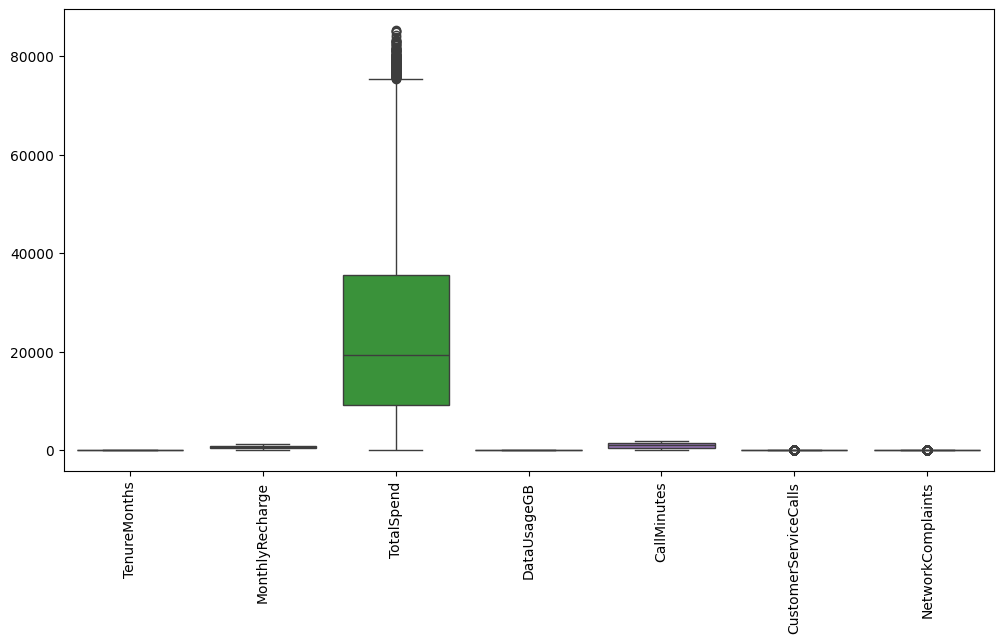

In [172]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(12,6))
sns.boxplot(data=data[num_cols])
plt.xticks(rotation=90)
plt.show()

##  Drop Unnecessary Column

In [173]:
data = data.drop(["CustomerID"], axis=1)

## Correlation Heatmap

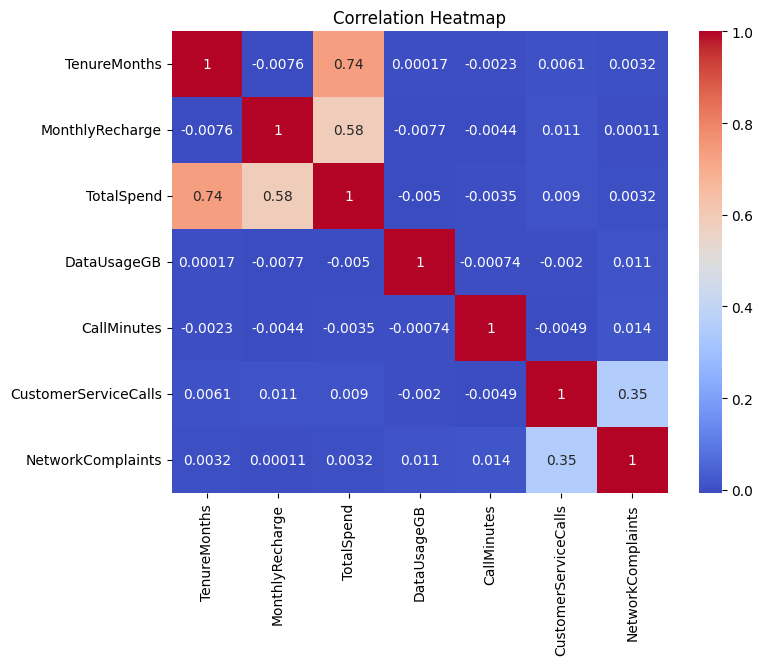

In [174]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Customer Churn Distribution

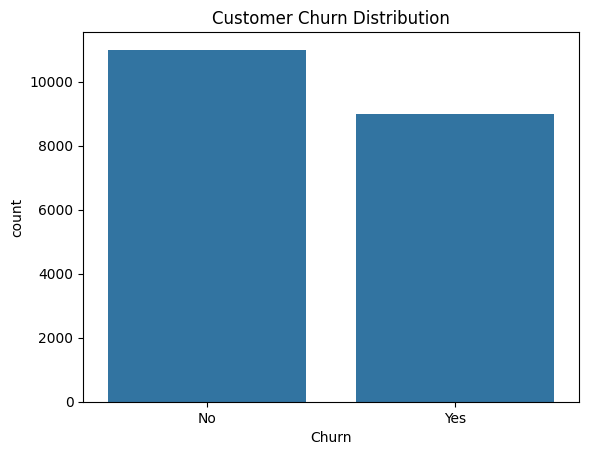

In [175]:
sns.countplot(x='Churn', data=data)
plt.title("Customer Churn Distribution")
plt.show()

## Internet Type vs Churn

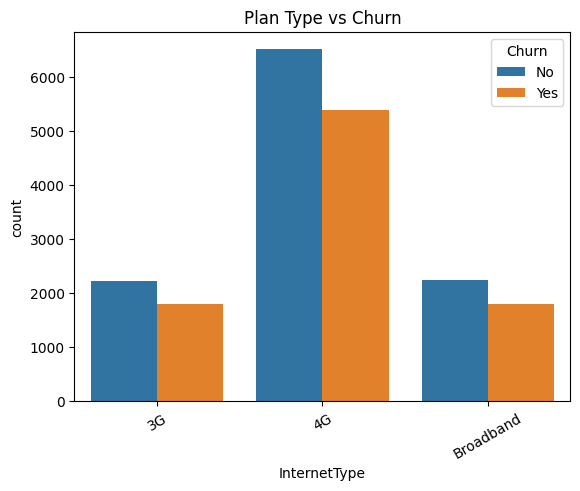

In [176]:
sns.countplot(x='InternetType', hue='Churn', data=data)
plt.title("Plan Type vs Churn")
plt.xticks(rotation=30)
plt.show()

## Customer Service Calls vs Churn


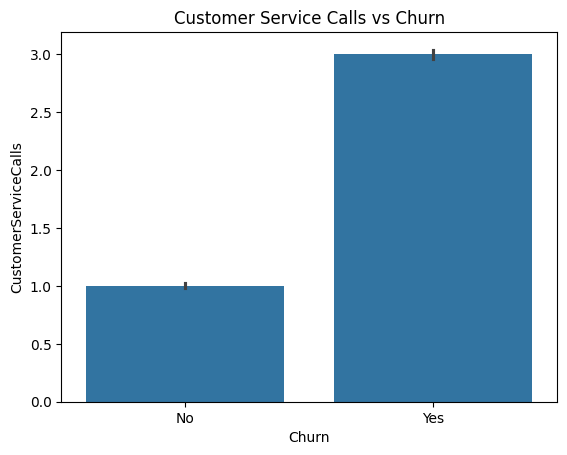

In [177]:
sns.barplot(x='Churn', y='CustomerServiceCalls', data=data)
plt.title("Customer Service Calls vs Churn")
plt.show()

## Network Complaints vs Churn

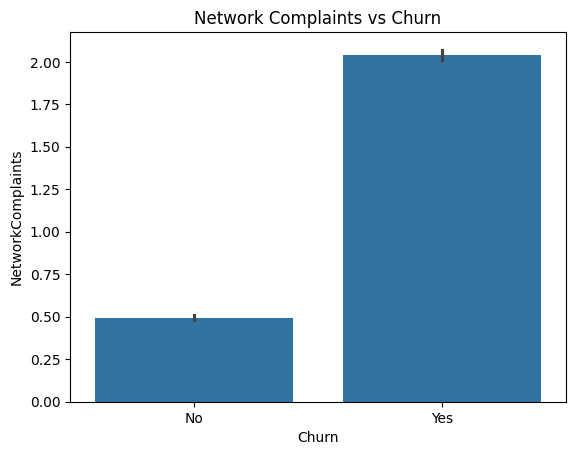

In [178]:
sns.barplot(x='Churn', y='NetworkComplaints', data=data)
plt.title("Network Complaints vs Churn")
plt.show()

## Encode Categorical Features


In [179]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()



data['PlanType'] = le.fit_transform(data['PlanType'])
data['InternetType'] = le.fit_transform(data['InternetType'])
data['Contract'] = le.fit_transform(data['Contract'])

## Frequency Encoding

In [180]:
freq_city = data['State'].value_counts()/len(data)
data['State'] = data['State'].map(freq_city)



In [181]:
data.head()

,State,PlanType,InternetType,Contract,TenureMonths,MonthlyRecharge,TotalSpend,DataUsageGB,CallMinutes,CustomerServiceCalls,NetworkComplaints,Churn
0,0.16530,1,0,1,35,358.56,12555.48,3.29,156,0,0,No
1,0.17100,1,1,1,68,432.77,29491.97,28.58,277,3,0,Yes
2,0.16460,1,1,1,15,165.84,2549.31,9.87,1381,1,0,No
3,0.17100,0,0,1,71,184.14,12877.34,20.35,1116,0,1,No
4,0.16365,1,2,1,58,649.61,37710.55,19.38,493,3,0,No


## Define Features and Target

In [182]:
X = data.drop('Churn', axis=1)
y = data['Churn']

## Train Test Split

In [183]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Random Forest Model

In [184]:
# Create model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8455


## Convert Target Variable
## Train XGBoost Model


In [185]:

# Convert target
data['Churn'] = data['Churn'].map({'No':0, 'Yes':1})

X = data.drop('Churn', axis=1)
y = data['Churn']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = XGBClassifier(
    n_estimators=350,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8465


## Model Evaluation

In [186]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8465


## Conclusion

This project predicts telecom customer churn using machine learning models.

Key insights:

- Customers with more service calls are likely to churn
- Network complaints increase churn probability
- Contract type influences customer retention

Models Used:

- Random Forest
- XGBoost

## Model Selection

After training multiple machine learning models, we compared their accuracy scores to select the best model for customer churn prediction.

| Model | Accuracy |
|------|---------|
| Random Forest | 0.84 |
| XGBoost | **0.8465** |

From the comparison, **XGBoost achieved the highest accuracy of 0.8465 (84.65%)**.

### Why XGBoost was chosen

- It produced the **highest prediction accuracy** among the tested models.
- XGBoost uses **gradient boosting**, which improves model performance by combining multiple weak learners.
- It handles **complex patterns and feature interactions** effectively.
- It is widely used in **real-world machine learning competitions and production systems**.

Therefore, **XGBoost was selected as the final model for customer churn prediction**.